# Part 1: NLP - Forum Post Classification

In [3]:
# Import Necessary Libraries
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from collections import Counter
from nltk.util import ngrams


In [5]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\12146\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\12146\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\12146\AppData\Roaming\nltk_data...


True

In [7]:
# Load 20 Newsgroups dataset
categories = ['comp.graphics', 'rec.autos', 'sci.space', 'talk.politics.misc']
newsgroups = fetch_20newsgroups(subset='train', categories=categories, random_state=42)

In [8]:
# Create DataFrame
df = pd.DataFrame({
    'text': newsgroups.data,
    'category': [newsgroups.target_names[target] for target in newsgroups.target]
})

print(df.head())


                                                text            category
0  From: nfotis@ntua.gr (Nick C. Fotis)\nSubject:...       comp.graphics
1  From: cdm@pmafire.inel.gov (Dale Cook)\nSubjec...  talk.politics.misc
2  From: rick@trystro.uucp (Richard Nickle)\nSubj...           sci.space
3  From: marshatt@feserve.cc.purdue.edu (Zauberer...           rec.autos
4  From: Clinton-HQ@Campaign92.Org (Clinton/Gore ...  talk.politics.misc


In [11]:
# Preprocessing function
def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = nltk.word_tokenize(text)
    if remove_stopwords:
        tokens = [t for t in tokens if t not in stopwords.words('english')]
    if lemmatize:
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens


In [17]:
# Apply preprocessing
df['processed_tokens'] = df['text'].apply(preprocess_text)

In [15]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\12146\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [19]:
# Token frequency analysis
counter = Counter([token for doc in df['processed_tokens'] for token in doc])
print('Top 20 words:', counter.most_common(20))

Top 20 words: [('line', 2586), ('subject', 2387), ('organization', 2307), ('would', 1969), ('writes', 1792), ('article', 1664), ('one', 1562), ('space', 1287), ('dont', 1282), ('car', 1262), ('like', 1209), ('university', 1149), ('get', 1147), ('people', 1119), ('know', 1059), ('think', 1050), ('time', 1036), ('nntppostinghost', 1021), ('u', 988), ('also', 963)]


In [21]:
# Bigram analysis
bigram_counts = Counter(ngrams([token for doc in df['processed_tokens'] for token in doc], 2))
print('Top 20 bigrams:', bigram_counts.most_common(20))

Top 20 bigrams: [(('line', 'article'), 607), (('writes', 'article'), 417), (('line', 'nntppostinghost'), 381), (('organization', 'university'), 374), (('mr', 'stephanopoulos'), 341), (('dont', 'know'), 210), (('distribution', 'world'), 207), (('line', 'distribution'), 204), (('usa', 'line'), 199), (('distribution', 'usa'), 146), (('dont', 'think'), 131), (('would', 'like'), 121), (('united', 'state'), 120), (('m', 'myers'), 117), (('world', 'nntppostinghost'), 116), (('university', 'line'), 114), (('anyone', 'know'), 111), (('state', 'university'), 110), (('im', 'sure'), 108), (('new', 'york'), 106)]


In [23]:
# Convert tokens back to string for vectorization
df['processed_text'] = df['processed_tokens'].apply(lambda tokens: ' '.join(tokens))

In [25]:
# Feature extraction using TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['processed_text'])
y = df['category']


In [27]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# Train Naive Bayes classifier
clf = MultinomialNB()
clf.fit(X_train, y_train)

MultinomialNB()

In [31]:
# Evaluate model
y_pred = clf.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9665178571428571
                    precision    recall  f1-score   support

     comp.graphics       0.96      0.97      0.97       119
         rec.autos       0.99      0.98      0.99       124
         sci.space       0.95      0.97      0.96       123
talk.politics.misc       0.96      0.93      0.94        82

          accuracy                           0.97       448
         macro avg       0.97      0.96      0.96       448
      weighted avg       0.97      0.97      0.97       448



# Part 2: Time Series Forecasting (S&P 500 example)

In [42]:
# Import Necessary Libraries
import pandas_datareader.data as web
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
import numpy as np

In [40]:
!pip install pandas-datareader

In [60]:
#Time Series Forecasting - S&P 500 using yfinance

import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Fetch data
start = '2015-01-01'
end = '2020-12-31'
sp500 = yf.download('^GSPC', start=start, end=end)


C:\Users\12146\AppData\Local\Temp\ipykernel_4712\3747278176.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download('^GSPC', start=start, end=end)
[*********************100%***********************]  1 of 1 completed


In [58]:
!pip install yfinance

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/949.2 kB ? eta -:--:--
     ------------------------------------- 949.2/949.2 kB 21.5 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 21.5 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15617 sha256=9fc95412a1742fb4292097d3192ebf9406ed45d929638d16632643acdda26a6a
  Stored in directory: c:\users\12146\appdata\local\pip\cache\wheels\cc\bd\6f\664d62c99327abeef7d86489e663

In [62]:
# Use closing prices
data_ts = sp500[['Close']].values
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data_ts)

In [64]:
# Prepare sequences
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

In [66]:
seq_length = 60
X_ts, y_ts = create_sequences(data_scaled, seq_length)
X_ts = X_ts.reshape((X_ts.shape[0], X_ts.shape[1], 1))


In [68]:
# Train-test split
train_size = int(len(X_ts)*0.8)
X_train_ts, X_test_ts = X_ts[:train_size], X_ts[train_size:]
y_train_ts, y_test_ts = y_ts[:train_size], y_ts[train_size:]

In [70]:
# LSTM Model
model_ts = Sequential()
model_ts.add(LSTM(50, return_sequences=True, input_shape=(X_train_ts.shape[1],1)))
model_ts.add(LSTM(50))
model_ts.add(Dense(1))
model_ts.compile(optimizer='adam', loss='mean_squared_error')

C:\Users\12146\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [72]:
# Train model
history = model_ts.fit(X_train_ts, y_train_ts, epochs=20, batch_size=32, validation_data=(X_test_ts, y_test_ts))


Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0168 - val_loss: 0.0102
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0010 - val_loss: 0.0049
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 6.7534e-04 - val_loss: 0.0056
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 6.2247e-04 - val_loss: 0.0050
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.3865e-04 - val_loss: 0.0045
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.9181e-04 - val_loss: 0.0043
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.4965e-04 - val_loss: 0.0042
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.5776e-04 - val_loss: 0.0042
Epoch 9/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.2954e-04 - val_loss: 0.0043
Epoch 10/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 5.4820e-04 - val_loss: 0.0043
Epoch 11/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 5.3427e-04 - val_loss: 0.0039
Epoch 12/20
37/37 ━━━━━━━━━

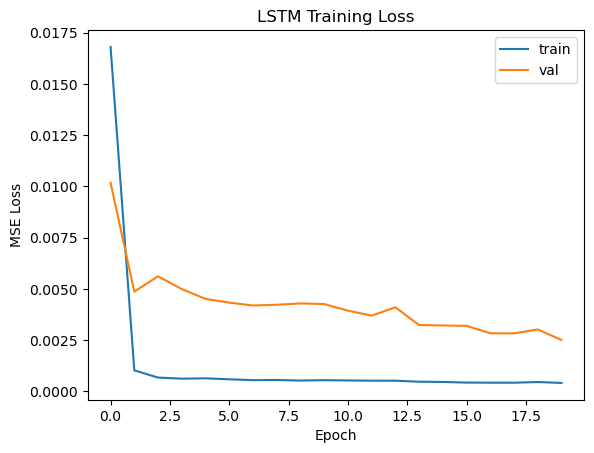

In [74]:
# Plot loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# Part 3: Neural Network Modeling

In [77]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits, load_wine
from sklearn.preprocessing import StandardScaler

In [79]:
# Part 3a: Image Classification (Digits dataset)
digits = load_digits()
X_img = digits.data
y_img = digits.target

In [81]:
# Scale features
scaler = StandardScaler()
X_img = scaler.fit_transform(X_img)

In [83]:
# Convert to PyTorch tensors
X_img_t = torch.tensor(X_img, dtype=torch.float32)
y_img_t = torch.tensor(y_img, dtype=torch.long)


In [85]:
# Train-test split
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(X_img_t, y_img_t, test_size=0.2, random_state=42)
train_ds_img = TensorDataset(X_train_img, y_train_img)
train_loader_img = DataLoader(train_ds_img, batch_size=32, shuffle=True)


In [87]:
# Define MLP
class ImageMLP(nn.Module):
    def __init__(self, input_size=64, hidden_size=128, num_classes=10):
        super(ImageMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [89]:
model_img = ImageMLP()
criterion_img = nn.CrossEntropyLoss()
optimizer_img = optim.Adam(model_img.parameters(), lr=0.001)

In [91]:
# Train model
for epoch in range(50):
    for batch_x, batch_y in train_loader_img:
        optimizer_img.zero_grad()
        outputs = model_img(batch_x)
        loss = criterion_img(outputs, batch_y)
        loss.backward()
        optimizer_img.step()
    if (epoch+1)%10==0:
        print(f'Epoch [{epoch+1}/50], Loss: {loss.item():.4f}')

Epoch [10/50], Loss: 0.0560
Epoch [20/50], Loss: 0.0227
Epoch [30/50], Loss: 0.0142
Epoch [40/50], Loss: 0.0019
Epoch [50/50], Loss: 0.0017


In [93]:
# Evaluate
model_img.eval()
with torch.no_grad():
    preds = torch.argmax(model_img(X_test_img), dim=1)
    acc = (preds == y_test_img).float().mean().item()
print('Image Classification Accuracy:', acc)

Image Classification Accuracy: 0.9777777791023254


In [95]:
# Part 3b: Numeric Regression (Wine dataset)
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  # for demo purposes, using target as numeric value

In [97]:
# Scale features
scaler = StandardScaler()
X_wine = scaler.fit_transform(X_wine)
X_wine_t = torch.tensor(X_wine, dtype=torch.float32)
y_wine_t = torch.tensor(y_wine, dtype=torch.float32).view(-1,1)

In [99]:
# Train-test split
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(X_wine_t, y_wine_t, test_size=0.2, random_state=42)
train_ds_wine = TensorDataset(X_train_wine, y_train_wine)
train_loader_wine = DataLoader(train_ds_wine, batch_size=16, shuffle=True)

In [101]:
# Define MLP
class WineMLP(nn.Module):
    def __init__(self, input_size=13, hidden_size=32):
        super(WineMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [103]:
model_wine = WineMLP()
criterion_wine = nn.MSELoss()
optimizer_wine = optim.Adam(model_wine.parameters(), lr=0.01)

In [105]:
# Train model
for epoch in range(100):
    for batch_x, batch_y in train_loader_wine:
        optimizer_wine.zero_grad()
        outputs = model_wine(batch_x)
        loss = criterion_wine(outputs, batch_y)
        loss.backward()
        optimizer_wine.step()
    if (epoch+1)%20==0:
        print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')

Epoch [20/100], Loss: 0.0216
Epoch [40/100], Loss: 0.0073
Epoch [60/100], Loss: 0.0044
Epoch [80/100], Loss: 0.0058
Epoch [100/100], Loss: 0.0016


In [107]:
# Evaluate
model_wine.eval()
with torch.no_grad():
    preds_wine = model_wine(X_test_wine)
    mse = nn.MSELoss()(preds_wine, y_test_wine).item()
    mae = nn.L1Loss()(preds_wine, y_test_wine).item()
print(f'Wine Regression MSE: {mse:.4f}, MAE: {mae:.4f}')

Wine Regression MSE: 0.0315, MAE: 0.1435
